# Fase 2: Filtros y Reducción de Dimensionalidad
En este cuaderno tomaremos la base de datos explorada y construiremos seis escenarios distintos de características (features) para evaluar posteriormente cuál ofrece el mejor rendimiento predictivo.

1. **Escenario 1 (Crudo):** Todas las características originales estandarizadas.
2. **Escenario 2 (Selección LASSO):** Selección algorítmica incrustada usando penalización L1.
3. **Escenario 3 (Mutual Information):** Filtro no lineal para capturar dependencias entrópicas.
4. **Escenario 4 (RFE):** Método Wrapper de eliminación recursiva.
5. **Escenario 5 (PCA):** Reducción de dimensionalidad no supervisada (95% de varianza).
6. **Escenario 6 (Discriminante de Fisher - LDA):** Transformación espacial supervisada.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel, SelectKBest, mutual_info_classif, RFE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos y Estandarización Base (Escenario 1)
Para esta fase de transformación, partimos de la **base de datos original e intacta** (cargada desde nuestro archivo local `dataset_cancer.csv` para agilizar el proceso). 

Dado que los algoritmos que utilizaremos para la selección y reducción son altamente sensibles a la magnitud geométrica de los datos, es **estrictamente necesario estandarizar** todas las variables (Z-score) antes de aplicar cualquier método. Esta matriz estandarizada completa será nuestro Escenario 1.

In [44]:
# Cargar el dataset desde la carpeta local
df = pd.read_csv('./data/dataset_cancer.csv')

# Separar variables independientes (X) y el objetivo (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Estandarización (Z-score)
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# Convertir de vuelta a DataFrame para no perder los nombres de las columnas
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

# Renombrar conceptualmente para claridad del proyecto
X_escenario_1 = X_scaled 

print("Datos cargados y estandarizados.")
print(f"Shape del Escenario 1 (Datos Crudos): {X_escenario_1.shape}")

Datos cargados y estandarizados.
Shape del Escenario 1 (Datos Crudos): (569, 30)


### Justificación Teórica: Sinergia entre Selección de Características y Modelos Predictivos
Para reducir el espacio dimensional de 30 variables a un subconjunto óptimo, hemos diseñado una estrategia basada en la naturaleza matemática de los clasificadores que utilizaremos en la Fase 3. 

Nuestra arquitectura de escenarios de datos contempla diversos campeones de selección:
* **Escenario LASSO:** Diseñado para optimizar nuestro modelo de Regresión Logística y combatir la multicolinealidad de forma multivariada.
* **Escenario Mutual Information (Información Mutua):** Se aplica este filtro agnóstico y no lineal para garantizar que algoritmos complejos reciban las características con relaciones no lineales.
* **Escenario RFE:** Método de envoltura que evalúa subconjuntos de características utilizando un algoritmo predictivo real.
* **Transformaciones espaciales:** Contrastaremos un enfoque no supervisado (PCA) frente a uno supervisado que maximiza la separación de clases (LDA - Fisher).

## 2. Escenario 2: Selección Incrustada con LASSO
Delegaremos la tarea de selección lineal a la regularización **L1 (LASSO)**. Entrenaremos una Regresión Logística con un nivel de penalización estricto (`C=1`) y usaremos `SelectFromModel` para extraer únicamente las variables cuyo coeficiente matemático haya sobrevivido (sea distinto de 0).

In [45]:
print("--- CREANDO ESCENARIO 2: SELECCIÓN LASSO ---")

# Configurar la Regresión Logística con penalización LASSO (L1)
modelo_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1, random_state=30)

# Selector de características basado en el modelo
selector = SelectFromModel(modelo_lasso)
selector.fit(X_scaled, y)

# Obtener los nombres de las variables que sobrevivieron
variables_lasso = X_scaled.columns[selector.get_support()]

# Crear el Escenario 2
X_lasso = X_scaled[variables_lasso]

print(f"Variables descartadas por LASSO: {X_scaled.shape[1] - len(variables_lasso)}")
print(f"Variables sobrevivientes ({len(variables_lasso)}):")
for var in variables_lasso:
    print(f"- {var}")
    
print(f"\nShape del Escenario 2 (LASSO): {X_lasso.shape}")

--- CREANDO ESCENARIO 2: SELECCIÓN LASSO ---
Variables descartadas por LASSO: 15
Variables sobrevivientes (15):
- concavity1
- concave_points1
- fractal_dimension1
- radius2
- texture2
- smoothness2
- compactness2
- fractal_dimension2
- radius3
- texture3
- area3
- smoothness3
- concavity3
- concave_points3
- symmetry3

Shape del Escenario 2 (LASSO): (569, 15)


### Justificación Teórica: Sinergia entre Selección de Características y Modelos Predictivos

Para reducir el espacio dimensional de 30 variables a un subconjunto óptimo, hemos diseñado una estrategia basada en la naturaleza matemática de los clasificadores que utilizaremos en la Fase 3. 

Se evaluaron diversas técnicas de la literatura, descartando enfoques univariados y categóricos por las siguientes razones clínicas y matemáticas:

1. **Descarte de Chi-Cuadrado ($\chi^2$):** Esta técnica está diseñada para evaluar frecuencias y variables categóricas. Dado que nuestras mediciones geométricas celulares (radio, textura, área) son variables continuas, forzar una prueba $\chi^2$ mediante escalado artificial comprometería la validez estadística del análisis.
2. **Descarte de ANOVA (F-Test) a favor de LASSO:** Aunque ANOVA F-test es un método de filtro válido para variables continuas, es estrictamente **univariado**. Es decir, evalúa el poder predictivo de cada característica de forma aislada, ignorando la redundancia. Por ello, hemos optado por utilizar **LASSO (Regularización L1)**, el cual es un método integrado (*Embedded Method*) que no solo evalúa el poder predictivo lineal, sino que aborda la multicolinealidad de forma **multivariada**, "apagando" coeficientes redundantes simultáneamente.
3. **El Contraste (Lineal vs. No Lineal):** Somos conscientes de que LASSO (al igual que la Correlación de Pearson) asume relaciones lineales. Extraerá las mejores variables para alimentar modelos lineales (como la Regresión Logística), pero podría descartar variables que posean relaciones complejas o curvas con el diagnóstico. 

Por esta razón, nuestra arquitectura de escenarios de datos contemplará dos grandes campeones de selección:
* **Escenario LASSO:** Diseñado para optimizar nuestro modelo de Regresión Logística.
* **Escenario Mutual Information (Información Mutua):** Se aplicará este filtro agnóstico y no lineal para garantizar que algoritmos complejos (como las Redes Neuronales y Random Forest) reciban las características con relaciones no lineales que necesitan para construir sus fronteras de decisión abstractas.

## 3. Escenario 3: Selección No Lineal (Mutual Information)
Para garantizar que nuestros modelos más abstractos (Redes Neuronales y Random Forest) reciban la información que necesitan, aplicaremos **Información Mutua (Mutual Information)**, el cual detecta cualquier tipo de dependencia no lineal. Seleccionaremos las **15 mejores características** para igualar la dimensionalidad.

In [46]:
print("--- CREANDO ESCENARIO 3: INFORMACIÓN MUTUA (MUTUAL INFO) ---")

# 1. Configurar y entrenar el selector para las 15 mejores variables
selector_mi = SelectKBest(score_func=mutual_info_classif, k=15)
selector_mi.fit(X_scaled, y)

# 2. Obtener las columnas ganadoras
mascara_mi = selector_mi.get_support()
columnas_elegidas_mi = X_scaled.columns[mascara_mi]
X_mutual_info = X_scaled[columnas_elegidas_mi]

# 3. Imprimir resultados
vars_descartadas_mi = len(X_scaled.columns) - len(columnas_elegidas_mi)
print(f"Variables descartadas por Mutual Information: {vars_descartadas_mi}")
print(f"Variables sobrevivientes ({len(columnas_elegidas_mi)}):")
for col in columnas_elegidas_mi:
    print(f"- {col}")

print(f"\nShape del Escenario 3 (Mutual Info): {X_mutual_info.shape}")

--- CREANDO ESCENARIO 3: INFORMACIÓN MUTUA (MUTUAL INFO) ---
Variables descartadas por Mutual Information: 15
Variables sobrevivientes (15):
- radius1
- perimeter1
- area1
- compactness1
- concavity1
- concave_points1
- radius2
- perimeter2
- area2
- radius3
- perimeter3
- area3
- compactness3
- concavity3
- concave_points3

Shape del Escenario 3 (Mutual Info): (569, 15)


## 4. Escenario 4: Método de Envoltura (Wrapper - RFE)
Utilizaremos la **Eliminación Recursiva de Características (RFE)** impulsada por una Regresión Logística. Forzaremos al algoritmo a seleccionar exactamente **15 variables** para realizar una comparación justa y directa contra los Escenarios de LASSO y Mutual Information.

In [47]:
print("--- CREANDO ESCENARIO 4: WRAPPER (RFE) ---")

# 1. Definir el estimador base
estimador_base = LogisticRegression(solver='liblinear', random_state=30)

# 2. Configurar RFE para forzar exactamente 15 variables
selector_rfe = RFE(estimator=estimador_base, n_features_to_select=15, step=1)

# 3. Entrenar el selector
selector_rfe.fit(X_scaled, y)

# 4. Obtener resultados
mascara_rfe = selector_rfe.support_
columnas_elegidas_rfe = X_scaled.columns[mascara_rfe]
X_wrapper_rfe = X_scaled[columnas_elegidas_rfe]

# 5. Imprimir resultados
vars_descartadas_rfe = len(X_scaled.columns) - len(columnas_elegidas_rfe)
print(f"Variables descartadas por RFE: {vars_descartadas_rfe}")
print(f"Variables sobrevivientes ({len(columnas_elegidas_rfe)}):")
for col in columnas_elegidas_rfe:
    print(f"- {col}")

print(f"\nShape del Escenario 4 (RFE): {X_wrapper_rfe.shape}")

--- CREANDO ESCENARIO 4: WRAPPER (RFE) ---
Variables descartadas por RFE: 15
Variables sobrevivientes (15):
- area1
- compactness1
- concave_points1
- radius2
- perimeter2
- area2
- compactness2
- radius3
- texture3
- perimeter3
- area3
- smoothness3
- concavity3
- concave_points3
- symmetry3

Shape del Escenario 4 (RFE): (569, 15)


## 5. Escenario 5: Transformación No Supervisada (PCA)
PCA no elimina variables, sino que las fusiona en un nuevo espacio geométrico. Extraeremos los Componentes Principales necesarios para encapsular el **95% de la información (varianza)** original de los tumores, eliminando la colinealidad al 100%.

--- CREANDO ESCENARIO 5: PCA ---
Componentes necesarios para explicar el 95% de la varianza: 10
Varianza total explicada: 95.16%

Tabla de Varianza Explicada:
Componente  Var. Individual (%)  Var. Acumulada (%)
       PC1                44.27               44.27
       PC2                18.97               63.24
       PC3                 9.39               72.64
       PC4                 6.60               79.24
       PC5                 5.50               84.73
       PC6                 4.02               88.76
       PC7                 2.25               91.01
       PC8                 1.59               92.60
       PC9                 1.39               93.99
      PC10                 1.17               95.16


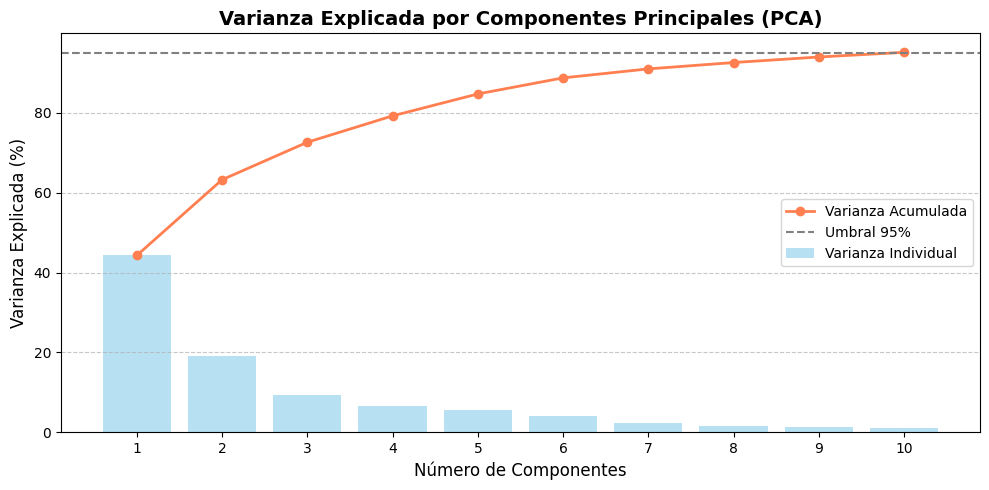

In [48]:
# --- CREANDO ESCENARIO 5: PCA ---
print("--- CREANDO ESCENARIO 5: PCA ---")

# Inicializar PCA para conservar el 95% de la varianza
pca = PCA(n_components=0.95, random_state=30)

# Ajustar y transformar los datos
X_pca_array = pca.fit_transform(X_scaled)

# Crear nombres para los nuevos componentes
nombres_pca = [f"PC{i+1}" for i in range(X_pca_array.shape[1])]
X_pca = pd.DataFrame(X_pca_array, columns=nombres_pca)

print(f"Componentes necesarios para explicar el 95% de la varianza: {pca.n_components_}")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

# --- NUEVO: TABLA Y GRÁFICO DE VARIANZA EXPLICADA (A PETICIÓN DE LA PROFE) ---
varianza_individual = pca.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza_individual)

# Crear y mostrar la tabla
df_pca_var = pd.DataFrame({
    'Componente': nombres_pca,
    'Var. Individual (%)': varianza_individual,
    'Var. Acumulada (%)': varianza_acumulada
})
print("Tabla de Varianza Explicada:")
print(df_pca_var.round(2).to_string(index=False))

# Dibujar el gráfico (Scree Plot)
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(varianza_individual) + 1), varianza_individual, alpha=0.6, color='skyblue', label='Varianza Individual')
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='coral', linewidth=2, label='Varianza Acumulada')
plt.axhline(y=95, color='gray', linestyle='--', label='Umbral 95%')

plt.title('Varianza Explicada por Componentes Principales (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Componentes', fontsize=12)
plt.ylabel('Varianza Explicada (%)', fontsize=12)
plt.xticks(range(1, len(varianza_individual) + 1))
plt.legend(loc='center right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análisis de Varianza Explicada y Dimensionalidad (PCA)

La aplicación del Análisis de Componentes Principales revela una dispersión significativa en la información morfológica de los tumores celulares. Al analizar la tabla de varianza acumulada, extraemos las siguientes conclusiones sobre la complejidad del dataset:

1. **Ausencia de un factor dominante único:** El primer componente principal (PC1) logra encapsular el 44.27% de la información original. Aunque es el vector más representativo, su porcentaje nos indica que las características del cáncer de mama son biológicamente complejas y no pueden resumirse a una única dimensión latente.
2. **Justificación de los 10 Componentes:** Aunque 10 componentes puede parecer una dimensionalidad alta para un PCA, está matemáticamente justificado. A partir del PC4, el aporte de cada nuevo componente decae significativamente (sumando entre 6% y 1%). Sin embargo, para cruzar el umbral estricto del 95% de retención de información —vital en un contexto oncológico para no perder patrones de malignidad— el algoritmo se ve obligado a retener hasta el PC10 (alcanzando un 95.16% acumulado).
3. **Beneficio del Escenario:** Esta transformación nos permite reducir el espacio de 30 variables altamente colineales a un subespacio de 10 dimensiones **100% ortogonales (independientes entre sí)**, eliminando el ruido redundante pero asegurando que los algoritmos de la siguiente fase reciban toda la varianza necesaria para evitar Falsos Negativos.

## 6. Escenario 6: Transformación Supervisada (Discriminante de Fisher - LDA)
A diferencia de PCA (que es no supervisado), el Discriminante de Fisher (LDA) sí conoce las etiquetas clínicas (Maligno vs Benigno). Su objetivo matemático es encontrar la proyección que separe lo mejor posible las dos clases. Dado que nuestro problema es binario, LDA reducirá las 30 variables originales a **1 solo componente discriminante**.

In [49]:
print("--- CREANDO ESCENARIO 6: DISCRIMINANTE DE FISHER (LDA) ---")

# Instanciamos el modelo. Al ser 2 clases, n_components será automáticamente 1
lda = LinearDiscriminantAnalysis()

# Ajustamos y transformamos usando las etiquetas 'y'
X_fisher_array = lda.fit_transform(X_scaled, y)

# Lo convertimos a DataFrame
X_fisher = pd.DataFrame(X_fisher_array, columns=['Componente_Fisher_1'])

print(f"Componentes extraídos por Fisher: {X_fisher.shape[1]}")
print(f"Shape del Escenario 6 (Fisher): {X_fisher.shape}")

--- CREANDO ESCENARIO 6: DISCRIMINANTE DE FISHER (LDA) ---
Componentes extraídos por Fisher: 1
Shape del Escenario 6 (Fisher): (569, 1)


## 7. Exportación de Escenarios
Finalmente, guardamos los 6 escenarios de características (junto con la variable objetivo `y`) en la carpeta `data/` para ser consumidos directamente por los algoritmos predictivos en la fase de **Estudio Comparativo (Notebook 03)**.

In [50]:
# Guardar los DataFrames transformados a CSV con la nueva nomenclatura
X_escenario_1.to_csv('./data/X_escenario_1_crudo.csv', index=False)
X_lasso.to_csv('./data/X_escenario_2_lasso.csv', index=False)
X_mutual_info.to_csv('./data/X_escenario_3_mutual_info.csv', index=False)
X_wrapper_rfe.to_csv('./data/X_escenario_4_rfe.csv', index=False)
X_pca.to_csv('./data/X_escenario_5_pca.csv', index=False)
X_fisher.to_csv('./data/X_escenario_6_fisher.csv', index=False)
y.to_csv('./data/y_target.csv', index=False)

print("¡Exportación de los 6 escenarios completada con éxito!")

¡Exportación de los 6 escenarios completada con éxito!


--- AUDITORÍA DE SUPERVIVENCIA DE VARIABLES ---


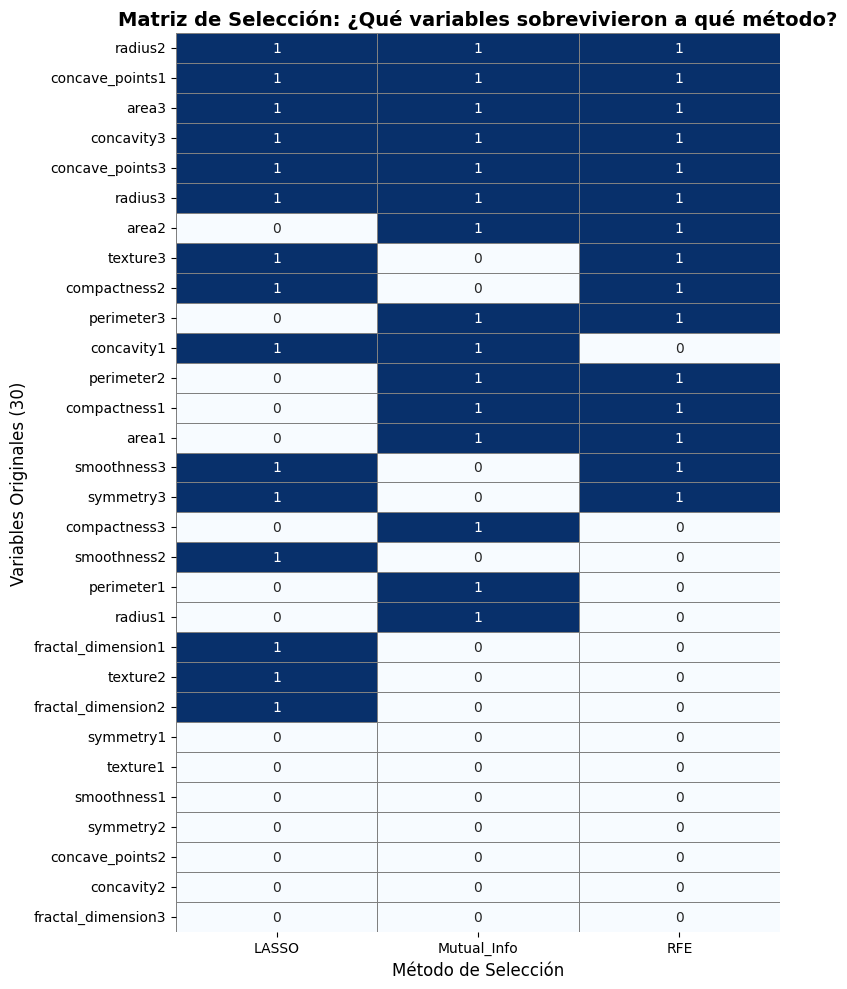

In [51]:
# =================================================================
# AUDITORÍA DE VARIABLES SELECCIONADAS (BENCHMARK DE MÉTODOS)
# =================================================================
print("--- AUDITORÍA DE SUPERVIVENCIA DE VARIABLES ---")

# Crear un DataFrame donde el índice son las 30 variables originales
resumen_vars = pd.DataFrame(index=X_scaled.columns)

# Si la variable está en el dataframe del escenario, se marca con 1, si no, con 0
resumen_vars['LASSO'] = resumen_vars.index.isin(X_lasso.columns).astype(int)
resumen_vars['Mutual_Info'] = resumen_vars.index.isin(X_mutual_info.columns).astype(int)
resumen_vars['RFE'] = resumen_vars.index.isin(X_wrapper_rfe.columns).astype(int)

# Sumar para ver cuáles variables son las "Favoritas" de todos los algoritmos
resumen_vars['Total_Votos'] = resumen_vars.sum(axis=1)

# Ordenar de las más votadas a las menos votadas
resumen_vars = resumen_vars.sort_values(by='Total_Votos', ascending=False)

# Crear un Heatmap visual para la profesora
plt.figure(figsize=(8, 10))
sns.heatmap(resumen_vars[['LASSO', 'Mutual_Info', 'RFE']], 
            cmap='Blues', cbar=False, linewidths=0.5, linecolor='gray', 
            annot=True, fmt="d")

plt.title('Matriz de Selección: ¿Qué variables sobrevivieron a qué método?', fontsize=14, fontweight='bold')
plt.ylabel('Variables Originales (30)', fontsize=12)
plt.xlabel('Método de Selección', fontsize=12)
plt.tight_layout()
plt.show()

## Conclusiones de la fase de selección de características

Al evaluar los resultados de los tres métodos de selección (LASSO, Mutual Information y RFE), la matriz de supervivencia de variables permite identificar patrones sobre qué información morfológica resulta más relevante para la clasificación de los tumores:

### 1. Consenso entre algoritmos
A pesar de utilizar enfoques matemáticos distintos (penalización L1, métodos basados en entropía y eliminación recursiva), los tres algoritmos coincidieron en conservar 6 características específicas:
* `concave_points1`, `radius2`, `radius3`, `area3`, `concavity3` y `concave_points3`.

Esto sugiere que la irregularidad en el contorno celular (`concavity` y `concave_points`) aporta un poder predictivo consistente para la detección de malignidad, independientemente de la naturaleza del modelo de selección.

### 2. Comportamiento de las mediciones: "Promedio" vs. "Peor valor"
Los resultados respaldan la decisión de no utilizar un filtro de correlación lineal estricto. Aunque variables como el radio promedio (`1`), el error estándar del radio (`2`) y el peor radio (`3`) derivan de la misma medida física, los algoritmos mostraron una preferencia por las variaciones extremas:
* Métodos penalizados como LASSO y RFE descartaron `radius1` (promedio), pero conservaron `radius2` y `radius3`.
* Un patrón similar se observó con la textura y la suavidad, donde las medidas de error estándar (`2`) y peor valor (`3`) fueron priorizadas.

Esto indica estadísticamente que los promedios tienden a suavizar los datos y pueden ocultar información. Los algoritmos priorizan las mediciones "Peor" porque capturan mejor la heterogeneidad y los picos de asimetría característicos de los tumores agresivos.

### 3. Diferencias según el tipo de método
Las características seleccionadas reflejan la naturaleza de cada técnica:
* **Mutual Information:** Al estar diseñado para detectar dependencias no lineales, retuvo principalmente variaciones de métricas geométricas de tamaño (`radius`, `perimeter` y `area`).
* **LASSO y RFE:** Al fundamentarse en modelos lineales, penalizaron la multicolinealidad evidente (por ejemplo, descartando redundancias entre perímetro y área) y optaron por un subconjunto más heterogéneo que incluye variaciones de `texture`, `smoothness` y `symmetry`.

Estos subconjuntos depurados, junto con las proyecciones espaciales generadas por PCA y el Discriminante de Fisher, estructuran los escenarios que se evaluarán en el estudio comparativo de los modelos predictivos.